# Loss Curves by Size (3 Raw Curves Per Size)

Compare the three raw curves within each model size. Each subplot clips to that size's common maximum step so that no plotted curve has missing values in the visible range.


In [74]:
from pathlib import Path
import csv
import math
import matplotlib.pyplot as plt

INPUT_DIR = Path('/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv')
OUTPUT_DIR = INPUT_DIR / 'plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

USE_LOG_Y = False
PLOT_DELTA = True
IGNORE_SMOOTH_COLUMNS = True
FIXED_MAX_STEP = 4242
FIXED_MIN_STEP = 600
LINESTYLES = ['-', '--', ':']

csv_paths = sorted(INPUT_DIR.glob('*.csv'))
csv_paths

[PosixPath('/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/194m.csv'),
 PosixPath('/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/296m.csv'),
 PosixPath('/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/436m.csv'),
 PosixPath('/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/528m.csv')]

In [75]:
def clean(text: str) -> str:
    return (text or '').replace('\ufeff', '').strip()

def short_run_name(col: str) -> str:
    parts = [p for p in clean(col).split('/') if p]
    if len(parts) >= 2:
        return parts[-2]
    return clean(col)

def load_raw_series(path: Path):
    with path.open('r', encoding='utf-8', newline='') as f:
        rows = list(csv.reader(f))
    if not rows or len(rows[0]) < 2:
        raise ValueError(f'Expected at least 2 columns in {path}')

    size_label = path.stem
    x_name = clean(rows[0][0]) or 'step'
    all_cols = [clean(c) for c in rows[0][1:]]
    series = []
    for col_idx, col in enumerate(all_cols):
        if IGNORE_SMOOTH_COLUMNS and '(smooth)' in col:
            continue
        xs = []
        ys = []
        for row in rows[1:]:
            if len(row) < len(all_cols) + 1:
                continue
            try:
                x = float(clean(row[0]))
                y = float(clean(row[col_idx + 1]))
            except ValueError:
                continue
            xs.append(x)
            ys.append(y)
        if xs:
            series.append({
                'size': size_label,
                'run_name': short_run_name(col),
                'x_name': x_name,
                'x': xs,
                'y': ys,
            })
    return size_label, x_name, series

loaded = []
for path in csv_paths:
    loaded.append(load_raw_series(path))

[(size, x_name, len(series), min(max(s['x']) for s in series)) for size, x_name, series in loaded]

[('194m', 'Step', 3, 4242.0),
 ('296m', 'Step', 3, 6767.0),
 ('436m', 'Step', 3, 6464.0),
 ('528m', 'Step', 3, 4747.0)]

In [76]:
len(series[0]['y'])

77

In [77]:
DISPLAY_NAMES_BY_RANK = ['Baseline', 'Residual Rotation', 'Value-Space Rotation']

def clip_series_within_size(series_list, min_step=FIXED_MIN_STEP, max_step=FIXED_MAX_STEP):
    common_max_step = float(max_step)
    common_min_step = float(min_step)
    clipped = []
    for s in series_list:
        pairs = [(x, y) for x, y in zip(s['x'], s['y']) if common_min_step <= x <= common_max_step]
        if not pairs:
            continue
        clipped.append({
            **s,
            'x': [x for x, _ in pairs],
            'y': [y for _, y in pairs],
        })
    clipped.sort(key=lambda s: s['y'][-1], reverse=True)
    renamed = []
    for idx, s in enumerate(clipped):
        name = DISPLAY_NAMES_BY_RANK[idx] if idx < len(DISPLAY_NAMES_BY_RANK) else f'Curve {idx+1}'
        renamed.append({**s, 'display_name': name})
    return common_max_step, renamed

prepared = []
for size, x_name, series in loaded:
    common_max_step, clipped = clip_series_within_size(series)
    prepared.append((size, x_name, common_max_step, clipped))

[(size, common_max_step, len(clipped)) for size, _, common_max_step, clipped in prepared]

[('194m', 4242.0, 3),
 ('296m', 4242.0, 3),
 ('436m', 4242.0, 3),
 ('528m', 4242.0, 3)]

In [91]:
prepared[-2][-1][0]

{'size': '436m',
 'run_name': 'run_20260417_eae7978c',
 'x_name': 'Step',
 'x': [606.0,
  707.0,
  808.0,
  909.0,
  1010.0,
  1111.0,
  1212.0,
  1313.0,
  1414.0,
  1515.0,
  1616.0,
  1717.0,
  1818.0,
  1919.0,
  2020.0,
  2121.0,
  2222.0,
  2323.0,
  2424.0,
  2525.0,
  2626.0,
  2727.0,
  2828.0,
  2929.0,
  3030.0,
  3131.0,
  3232.0,
  3333.0,
  3434.0,
  3535.0,
  3636.0,
  3737.0,
  3838.0,
  3939.0,
  4040.0,
  4141.0,
  4242.0],
 'y': [3.222839,
  3.160045,
  3.116888,
  3.103606,
  3.06042,
  3.050497,
  3.012536,
  3.015169,
  2.986449,
  2.987178,
  2.954642,
  2.955034,
  2.955533,
  2.93889,
  2.929367,
  2.924761,
  2.918302,
  2.911836,
  2.904566,
  2.947712,
  2.910096,
  2.903166,
  2.901237,
  2.888234,
  2.8945,
  2.909609,
  2.884955,
  2.889964,
  2.881161,
  2.885879,
  2.875612,
  2.857519,
  3.107952,
  2.914199,
  2.904975,
  2.891004,
  2.964845],
 'display_name': 'Baseline'}

In [ ]:
def plot_grid(prepared, delta=False, use_log_y=False, figsize=(11.0, 8.2)):
    n = len(prepared)
    cols = 2
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()

    for ax in axes_flat[n:]:
        ax.axis('off')

    for ax, (size, x_name, common_max_step, series_list) in zip(axes_flat, prepared):
        for idx, s in enumerate(series_list):
            ys = s['y']
            ylabel = 'val loss'
            if delta:
                base = ys[0]
                ys = [y - base for y in ys]
                ylabel = 'val loss - first point'
            ax.plot(s['x'], ys, linewidth=2.0, linestyle=LINESTYLES[idx % len(LINESTYLES)], label=s.get('display_name', f'{size}-{idx+1}'))
        ax.set_title(f'{size} ({int(FIXED_MIN_STEP)} to {int(common_max_step)})')
        ax.set_xlabel(x_name)
        ax.set_ylabel(ylabel)
        if use_log_y and not delta:
            ax.set_yscale('log')
        if delta:
            ax.axhline(0.0, color='gray', linestyle='--', linewidth=1)
        ax.grid(alpha=0.25, linestyle=':')
        ax.legend(frameon=True, fontsize=8, facecolor='white', edgecolor='#cfcfcf')

    title = 'Loss Curves by Size (3 raw curves each)'
    if delta:
        title += ' (relative to first point)'
    fig.suptitle(title, y=0.995)
    fig.tight_layout()
    return fig


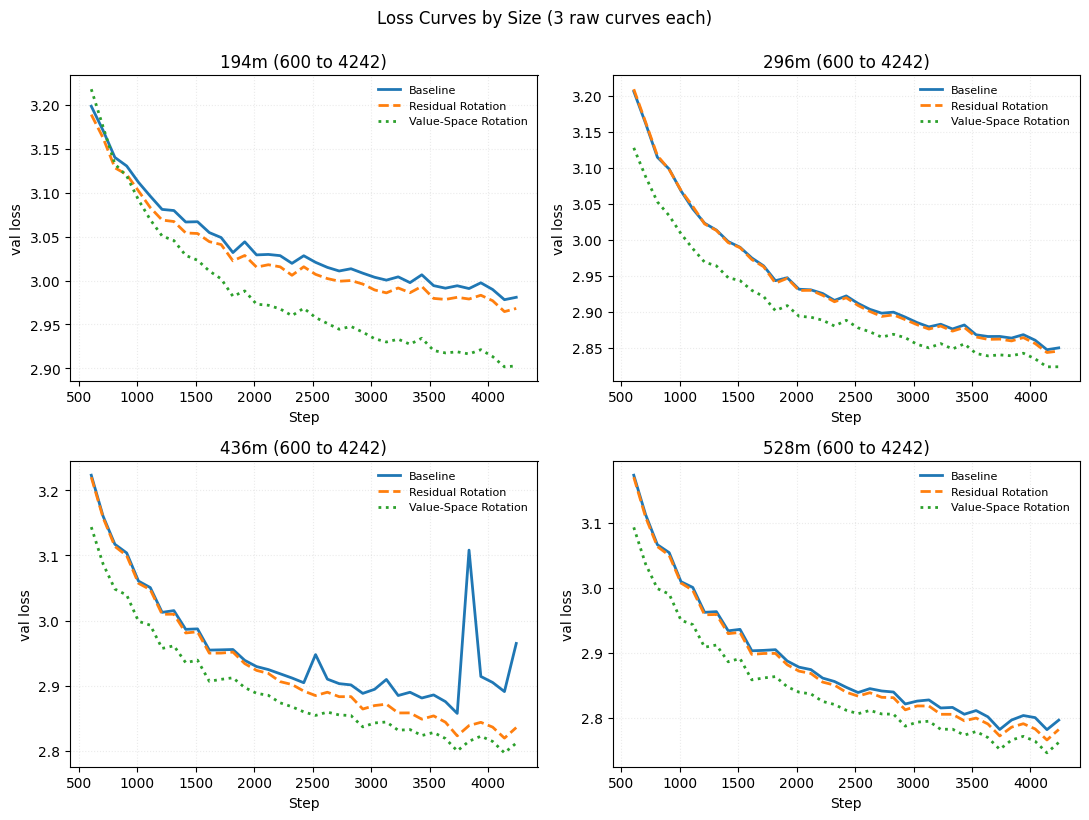

In [79]:
fig = plot_grid(prepared, delta=False, use_log_y=USE_LOG_Y)
plt.show()

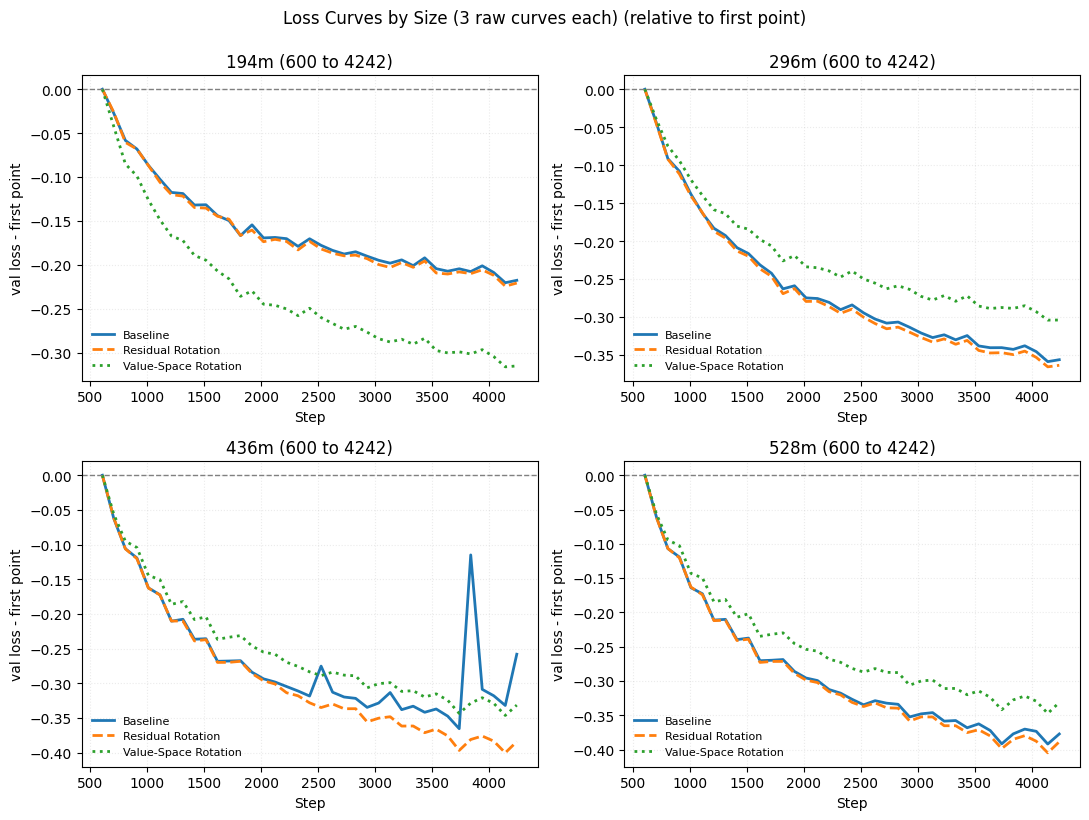

In [80]:
if PLOT_DELTA:
    fig = plot_grid(prepared, delta=True, use_log_y=USE_LOG_Y)
    plt.show()

In [81]:
suffix = '_logy' if USE_LOG_Y else ''
abs_path = OUTPUT_DIR / f'loss_csv_by_size_raw3_from_notebook{suffix}.png'
fig = plot_grid(prepared, delta=False, use_log_y=USE_LOG_Y)
fig.savefig(abs_path, dpi=220)
plt.close(fig)
print(abs_path)

if PLOT_DELTA:
    delta_path = OUTPUT_DIR / f'loss_csv_by_size_raw3_delta_from_notebook{suffix}.png'
    fig = plot_grid(prepared, delta=True, use_log_y=USE_LOG_Y)
    fig.savefig(delta_path, dpi=220)
    plt.close(fig)
    print(delta_path)

/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/plots/loss_csv_by_size_raw3_from_notebook.png
/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/plots/loss_csv_by_size_raw3_delta_from_notebook.png


In [82]:
import pandas as pd

rows = []
for size, x_name, common_max_step, series_list in prepared:
    for s in series_list:
        for x, y in zip(s['x'], s['y']):
            rows.append({
                'model_size': size,
                'curve_name': s.get('display_name', s.get('run_name', 'unknown')),
                'original_run_name': s.get('run_name', ''),
                'x_name': x_name,
                'step': x,
                'val_loss': y,
                'clip_min_step': FIXED_MIN_STEP,
                'clip_max_step': common_max_step,
            })

clean_df = pd.DataFrame(rows)
excel_path = OUTPUT_DIR / 'loss_csv_by_size_raw3_cleaned.xlsx'
csv_path = OUTPUT_DIR / 'loss_csv_by_size_raw3_cleaned.csv'
clean_df.to_csv(csv_path, index=False)
print(csv_path)
try:
    clean_df.to_excel(excel_path, index=False)
    print(excel_path)
except ModuleNotFoundError:
    print('openpyxl not installed, skip xlsx export')
clean_df.head()


/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/plots/loss_csv_by_size_raw3_cleaned.csv
openpyxl not installed, skip xlsx export


,model_size,curve_name,original_run_name,x_name,step,val_loss,clip_min_step,clip_max_step
0,194m,Baseline,run_20260412_485afd31,Step,606.0,3.198532,600,4242.0
1,194m,Baseline,run_20260412_485afd31,Step,707.0,3.170893,600,4242.0
2,194m,Baseline,run_20260412_485afd31,Step,808.0,3.140183,600,4242.0
3,194m,Baseline,run_20260412_485afd31,Step,909.0,3.130445,600,4242.0
4,194m,Baseline,run_20260412_485afd31,Step,1010.0,3.111854,600,4242.0


In [93]:
#!/usr/bin/env python3
from __future__ import annotations

from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd


# =========================
# File-first configuration
# =========================
CLEANED_CSV = Path(
    "/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/plots/loss_csv_by_size_raw3_cleaned.csv"
)
RAW_LOSS_DIR = Path(
    "/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv"
)
OUTPUT_DIR = RAW_LOSS_DIR / "plots"
FIG_DPI = 220
USE_LOG_Y = False
PLOT_DELTA = True
FIGSIZE = (11.0, 8.0)
LINESTYLES = {
    "Baseline": "-",
    "Residual Rotation": "--",
    "Value-Space Rotation": ":",
}
SIZE_ORDER = ["194m", "296m", "436m", "528m"]
SIZE_COLORS = {
    "194m": "#1f77b4",
    "296m": "#ff7f0e",
    "436m": "#2ca02c",
    "528m": "#d62728",
}
FIXED_MIN_STEP = 600
FIXED_MAX_STEP = 4242


def _plot_from_cleaned_csv(df: pd.DataFrame, out_prefix: str) -> list[Path]:
    outputs: list[Path] = []
    fig, axes = plt.subplots(2, 2, figsize=FIGSIZE, squeeze=False)
    axes_flat = axes.flatten()

    for ax, size in zip(axes_flat, SIZE_ORDER):
        sdf = df[df["model_size"] == size].copy()
        if sdf.empty:
            ax.axis("off")
            continue
        for curve_name in ["Baseline", "Residual Rotation", "Value-Space Rotation"]:
            cdf = sdf[sdf["curve_name"] == curve_name].sort_values("step")
            if cdf.empty:
                continue
            ax.plot(
                cdf["step"],
                cdf["val_loss"],
                linewidth=2.0,
                linestyle=LINESTYLES.get(curve_name, "-"),
                color=SIZE_COLORS.get(size),
                label=curve_name,
            )
        clip_min = sdf["clip_min_step"].iloc[0]
        clip_max = sdf["clip_max_step"].iloc[0]
        ax.set_title(f"{size} ({int(float(clip_min))} to {int(float(clip_max))})")
        ax.set_xlabel(sdf["x_name"].iloc[0])
        ax.set_ylabel("val loss")
        if USE_LOG_Y:
            ax.set_yscale("log")
        ax.grid(alpha=0.25, linestyle=":")
        ax.legend(frameon=True, fontsize=8, facecolor='white', edgecolor='#cfcfcf')

    fig.suptitle("Loss Curves by Size (cleaned CSV)", y=0.995)
    fig.tight_layout()
    out = OUTPUT_DIR / f"{out_prefix}_absolute.png"
    fig.savefig(out, dpi=FIG_DPI)
    plt.close(fig)
    outputs.append(out)

    if PLOT_DELTA:
        fig, axes = plt.subplots(2, 2, figsize=FIGSIZE, squeeze=False)
        axes_flat = axes.flatten()
        for ax, size in zip(axes_flat, SIZE_ORDER):
            sdf = df[df["model_size"] == size].copy()
            if sdf.empty:
                ax.axis("off")
                continue
            for curve_name in ["Baseline", "Residual Rotation", "Value-Space Rotation"]:
                cdf = sdf[sdf["curve_name"] == curve_name].sort_values("step")
                if cdf.empty:
                    continue
                base = float(cdf["val_loss"].iloc[0])
                ax.plot(
                    cdf["step"],
                    cdf["val_loss"] - base,
                    linewidth=2.0,
                    linestyle=LINESTYLES.get(curve_name, "-"),
                    color=SIZE_COLORS.get(size),
                    label=curve_name,
                )
            clip_min = sdf["clip_min_step"].iloc[0]
            clip_max = sdf["clip_max_step"].iloc[0]
            ax.set_title(f"{size} ({int(float(clip_min))} to {int(float(clip_max))})")
            ax.set_xlabel(sdf["x_name"].iloc[0])
            ax.set_ylabel("val loss - first point")
            ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
            ax.grid(alpha=0.25, linestyle=":")
            ax.legend(frameon=True, fontsize=8, facecolor='white', edgecolor='#cfcfcf')

        fig.suptitle("Loss Delta by Size (cleaned CSV)", y=0.995)
        fig.tight_layout()
        out = OUTPUT_DIR / f"{out_prefix}_delta.png"
        fig.savefig(out, dpi=FIG_DPI)
        # plt.close(fig)
        outputs.append(out)

    return outputs


def _clean(text: str) -> str:
    return (text or "").replace("\ufeff", "").strip()


def _short_run_name(col: str) -> str:
    parts = [p for p in _clean(col).split("/") if p]
    if len(parts) >= 2:
        return parts[-2]
    return _clean(col)


def _load_raw_size_series(csv_path: Path) -> pd.DataFrame:
    import csv

    with csv_path.open("r", encoding="utf-8", newline="") as f:
        rows = list(csv.reader(f))
    header = [_clean(c) for c in rows[0]]
    x_name = header[0] or "step"
    size = csv_path.stem
    raw_cols = [c for c in header[1:] if "(smooth)" not in c]
    series_rows = []
    display_names = ["Baseline", "Residual Rotation", "Value-Space Rotation"]
    for idx, col in enumerate(raw_cols[:3]):
        curve_name = display_names[idx] if idx < len(display_names) else f"Curve {idx+1}"
        col_idx = header.index(col)
        for row in rows[1:]:
            if len(row) <= col_idx:
                continue
            try:
                step = float(_clean(row[0]))
                val = float(_clean(row[col_idx]))
            except ValueError:
                continue
            if not (FIXED_MIN_STEP <= step <= FIXED_MAX_STEP):
                continue
            series_rows.append(
                {
                    "model_size": size,
                    "curve_name": curve_name,
                    "original_run_name": _short_run_name(col),
                    "x_name": x_name,
                    "step": step,
                    "val_loss": val,
                    "clip_min_step": FIXED_MIN_STEP,
                    "clip_max_step": FIXED_MAX_STEP,
                }
            )
    return pd.DataFrame(series_rows)


def main() -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    if CLEANED_CSV.exists():
        df = pd.read_csv(CLEANED_CSV)
        outputs = _plot_from_cleaned_csv(df, "loss_csv_by_size_raw3_cleaned_from_script")
        print("[INFO] source=cleaned_csv")
        for path in outputs:
            print(path)
        return

    csv_paths = [RAW_LOSS_DIR / f"{size}.csv" for size in SIZE_ORDER if (RAW_LOSS_DIR / f"{size}.csv").exists()]
    if not csv_paths:
        raise SystemExit(
            "Cleaned CSV not found and no raw size CSVs found under "
            f"{RAW_LOSS_DIR}"
        )
    frames = [_load_raw_size_series(path) for path in csv_paths]
    df = pd.concat(frames, ignore_index=True)
    outputs = _plot_from_cleaned_csv(df, "loss_csv_by_size_raw3_fallback_raw")
    print("[INFO] source=raw_csv_fallback")
    for path in outputs:
        print(path)
    return


if __name__ == "__main__":
    main()


[INFO] source=cleaned_csv
/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/plots/loss_csv_by_size_raw3_cleaned_from_script_absolute.png
/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/plots/loss_csv_by_size_raw3_cleaned_from_script_delta.png
